In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import *

apply_plot_style()
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

In [2]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

results = pd.read_csv(FIGURES_DIR / "model_results.csv").set_index("model")
preds = pd.read_csv(PROCESSED_DIR / "predictions.csv")
models = [m for m in MODEL_LABELS if m in set(preds.model)]

print(f"{len(models)} models, {len(preds)//max(1,len(models))} test records each")
results

5 models, 141 test records each


,roc_auc,pr_auc,accuracy,precision,recall,f1,mcc,brier,seconds
model,,,,,,,,,
1_tabfm_raw,0.9532,0.9445,0.8723,0.8615,0.8615,0.8615,0.7431,0.0885,138.1939
2_tabfm_preprocessed,0.9389,0.9332,0.8298,0.8361,0.7846,0.8095,0.6570,0.1025,99.2929
3_logistic_regression,0.9413,0.9371,0.8369,0.8500,0.7846,0.8160,0.6717,0.1005,4.2016
4_random_forest,0.9326,0.9177,0.8369,0.8500,0.7846,0.8160,0.6717,0.1130,3.5480
5_xgboost,0.9332,0.9227,0.8298,0.8475,0.7692,0.8065,0.6576,0.1103,1.3229


In [3]:
table = results.loc[models].rename(index=MODEL_LABELS).rename(columns=METRIC_NAMES)
table.index.name = "Model"
table.to_csv(FIGURES_DIR / "table_7_1_results.csv")
(FIGURES_DIR / "table_7_1_results.tex").write_text(
    table.to_latex(float_format="%.3f",
                   caption="Test-set performance. The baseline is a prior-probability predictor.",
                   label="tab:results"), encoding="utf-8")
table

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,MCC,Brier,Seconds
Model,,,,,,,,,
TabFM (raw),0.9532,0.9445,0.8723,0.8615,0.8615,0.8615,0.7431,0.0885,138.1939
TabFM (preprocessed),0.9389,0.9332,0.8298,0.8361,0.7846,0.8095,0.6570,0.1025,99.2929
Logistic regression,0.9413,0.9371,0.8369,0.8500,0.7846,0.8160,0.6717,0.1005,4.2016
Random forest,0.9326,0.9177,0.8369,0.8500,0.7846,0.8160,0.6717,0.1130,3.5480
XGBoost,0.9332,0.9227,0.8298,0.8475,0.7692,0.8065,0.6576,0.1103,1.3229


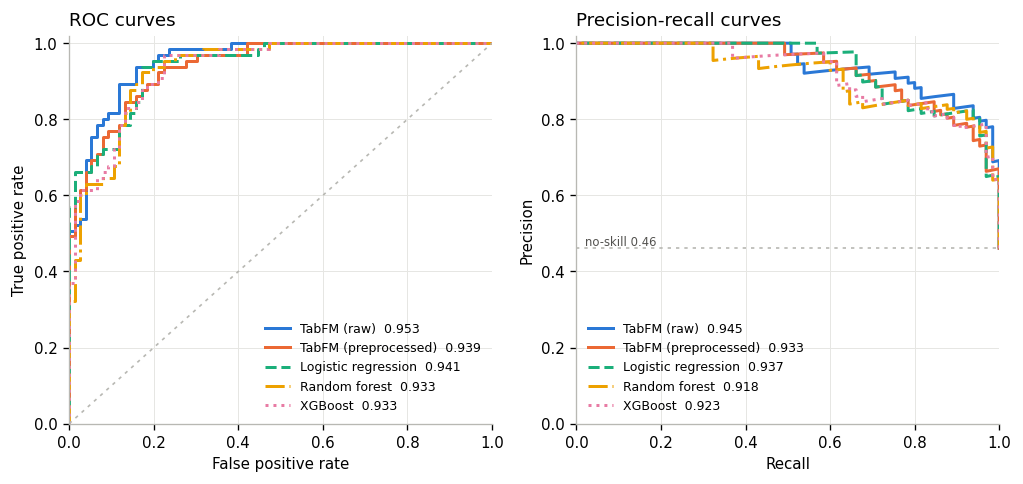

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

for i, m in enumerate(models):
    d = preds[preds.model == m]
    fpr, tpr, _ = roc_curve(d.y_true, d.prob)
    ax1.plot(fpr, tpr, color=MODEL_COLOURS[m], linestyle=MODEL_DASH[m], linewidth=1.8,
             label=f"{MODEL_LABELS[m]}  {results.loc[m, 'roc_auc']:.3f}")
    precision, recall, _ = precision_recall_curve(d.y_true, d.prob)
    ax2.plot(recall, precision, color=MODEL_COLOURS[m], linestyle=MODEL_DASH[m], linewidth=1.8,
             label=f"{MODEL_LABELS[m]}  {results.loc[m, 'pr_auc']:.3f}")

ax1.plot([0, 1], [0, 1], color="#b8b8b3", linewidth=1, linestyle=(0, (2, 3)))
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curves", loc="left", fontsize=11)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02); ax1.legend(loc="lower right", fontsize=7.5)

base = preds[preds.model == models[0]].y_true.mean()
ax2.axhline(base, color="#b8b8b3", linewidth=1, linestyle=(0, (2, 3)))
ax2.annotate(f"no-skill {base:.2f}", (0.02, base), fontsize=7, color="#52514e", va="bottom")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-recall curves", loc="left", fontsize=11)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02); ax2.legend(loc="lower left", fontsize=7.5)

fig.savefig(FIGURES_DIR / "roc_pr_curves.png")
plt.show()

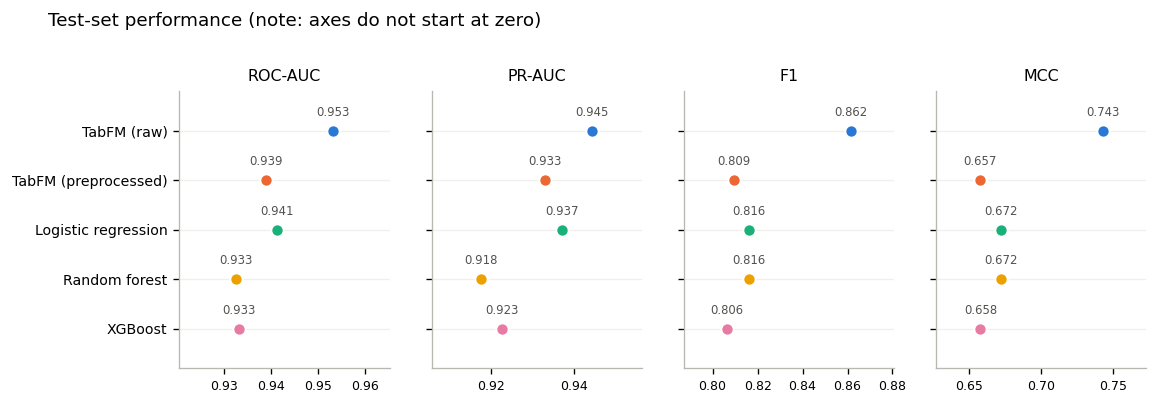

In [5]:
HEADLINE = ["roc_auc", "pr_auc", "f1", "mcc"]
fig, axes = plt.subplots(1, len(HEADLINE), figsize=(2.6 * len(HEADLINE), 3.0), sharey=True)
y = np.arange(len(models))[::-1]

for ax, key in zip(np.atleast_1d(axes), HEADLINE):
    vals = np.array([results.loc[m, key] for m in models])
    for yi, m, v in zip(y, models, vals):
        ax.axhline(yi, color="#efefec", linewidth=0.8, zorder=0)
        ax.scatter(v, yi, s=55, color=MODEL_COLOURS[m], edgecolor="white",
                   linewidth=1.2, zorder=3)
        ax.annotate(f"{v:.3f}", (v, yi), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7, color="#52514e")
    pad = max(0.012, (vals.max() - vals.min()) * 0.35)
    ax.set_xlim(vals.min() - pad, vals.max() + pad)
    ax.set_title(METRIC_NAMES[key], fontsize=9.5)
    ax.tick_params(axis="x", labelsize=7.5)
    ax.grid(False)

axes[0].set_yticks(y, [MODEL_LABELS[m] for m in models], fontsize=8.5)
axes[0].set_ylim(-0.8, len(models) - 0.2)
fig.suptitle("Test-set performance (note: axes do not start at zero)", x=0.02, y=1.10,
             ha="left", fontsize=11)
fig.savefig(FIGURES_DIR / "metric_comparison.png")
plt.show()

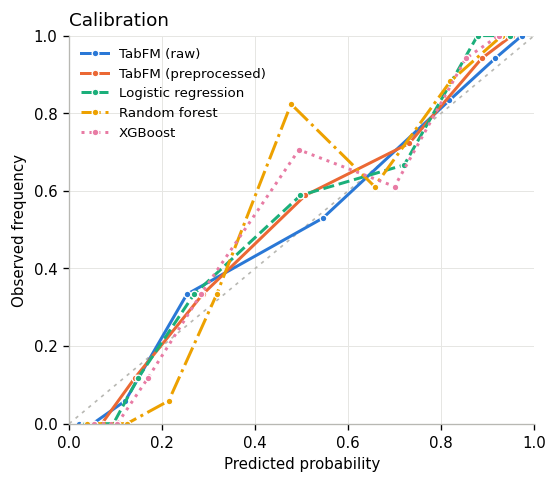

In [6]:
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot([0, 1], [0, 1], color="#b8b8b3", linewidth=1, linestyle=(0, (2, 3)))
for i, m in enumerate(models):
    d = preds[preds.model == m]
    if d.prob.nunique() < 3:
        continue
    frac, mean_pred = calibration_curve(d.y_true, d.prob, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac, color=MODEL_COLOURS[m], linestyle=MODEL_DASH[m], linewidth=1.8,
            marker="o", markersize=4, markeredgecolor="white", markeredgewidth=0.8,
            label=MODEL_LABELS[m])
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Calibration", loc="left", fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left", fontsize=8)
fig.savefig(FIGURES_DIR / "calibration.png")
plt.show()

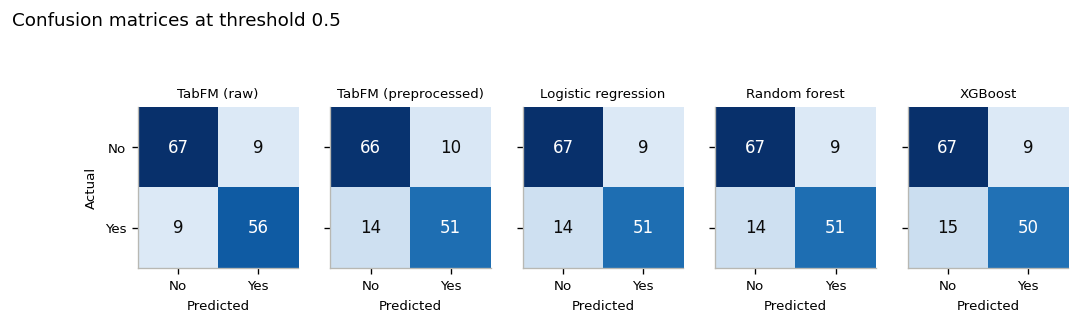

In [7]:
mats = {m: confusion_matrix(preds[preds.model == m].y_true,
                            (preds[preds.model == m].prob >= 0.5).astype(int))
        for m in models}
top = max(cm.max() for cm in mats.values())

fig, axes = plt.subplots(1, len(models), figsize=(2.0 * len(models), 2.6))
for i, (ax, m) in enumerate(zip(np.atleast_1d(axes), models)):
    cm = mats[m]
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=top)
    for (r, c), v in np.ndenumerate(cm):
        ax.text(c, r, v, ha="center", va="center", fontsize=10,
                color="white" if v > top * 0.55 else "#0b0b0b")
    ax.set_xticks([0, 1], ["No", "Yes"], fontsize=8)
    ax.set_yticks([0, 1], ["No", "Yes"] if i == 0 else ["", ""], fontsize=8)
    ax.set_title(MODEL_LABELS[m], fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.grid(False)
axes[0].set_ylabel("Actual", fontsize=8)
fig.suptitle("Confusion matrices at threshold 0.5", x=0.02, y=1.06, ha="left", fontsize=11)
fig.savefig(FIGURES_DIR / "confusion_matrices.png")
plt.show()

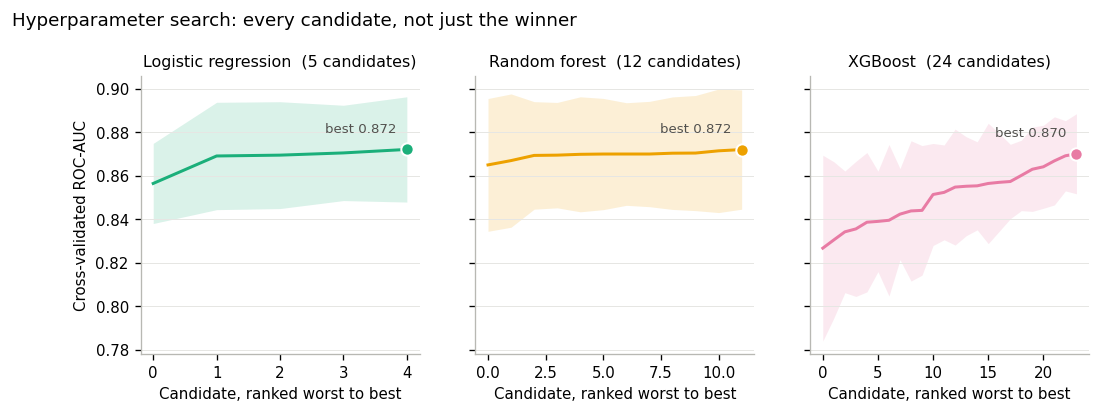

In [8]:
trace_path = FIGURES_DIR / "tuning_trace.csv"
if trace_path.exists():
    trace = pd.read_csv(trace_path)
    tuned = [m for m in models if m in set(trace.model)]
    fig, axes = plt.subplots(1, len(tuned), figsize=(3.4 * len(tuned), 3.0), sharey=True)
    for ax, m in zip(np.atleast_1d(axes), tuned):
        d = trace[trace.model == m].sort_values("mean_test_score").reset_index(drop=True)
        x = np.arange(len(d))
        colour = MODEL_COLOURS[m]
        ax.fill_between(x, d.mean_test_score - d.std_test_score,
                        d.mean_test_score + d.std_test_score,
                        color=colour, alpha=0.16, linewidth=0)
        ax.plot(x, d.mean_test_score, color=colour, linewidth=1.8)
        ax.scatter([len(d) - 1], [d.mean_test_score.iloc[-1]], s=55, color=colour,
                   edgecolor="white", linewidth=1.2, zorder=3)
        ax.annotate(f"best {d.mean_test_score.iloc[-1]:.3f}",
                    (len(d) - 1, d.mean_test_score.iloc[-1]), textcoords="offset points",
                    xytext=(-6, 10), ha="right", fontsize=8, color="#52514e")
        ax.set_title(f"{MODEL_LABELS[m]}  ({len(d)} candidates)", fontsize=9.5)
        ax.set_xlabel("Candidate, ranked worst to best")
        ax.grid(axis="x", visible=False)
    np.atleast_1d(axes)[0].set_ylabel("Cross-validated ROC-AUC")
    fig.suptitle("Hyperparameter search: every candidate, not just the winner",
                 x=0.02, y=1.06, ha="left", fontsize=11)
    fig.savefig(FIGURES_DIR / "tuning_trend.png")
    plt.show()
else:
    print("no tuning trace found - run notebook 04 first")

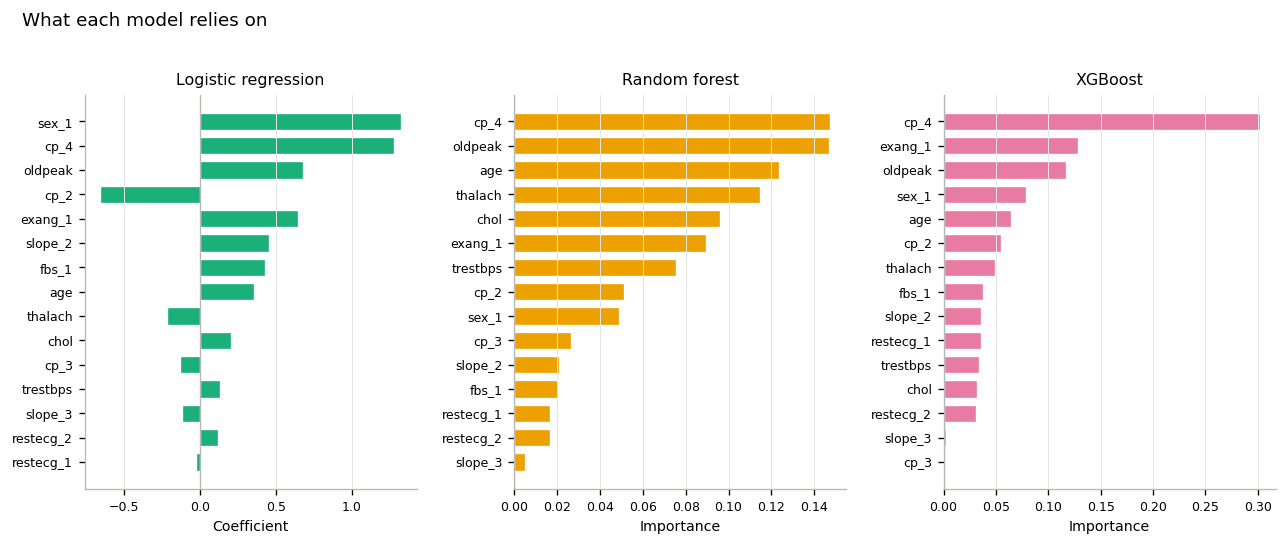

In [9]:
import joblib

panels = []
for m in models:
    path = MODELS_DIR / f"{m}.joblib"
    fpath = MODELS_DIR / f"{m}_features.joblib"
    if not path.exists() or not fpath.exists():
        continue
    est = joblib.load(path)
    names = joblib.load(fpath)
    if hasattr(est, "feature_importances_"):
        panels.append((m, names, est.feature_importances_, "Importance"))
    elif hasattr(est, "coef_"):
        panels.append((m, names, est.coef_.ravel(), "Coefficient"))

if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 4.4))
    for ax, (m, names, vals, label) in zip(np.atleast_1d(axes), panels):
        order = np.argsort(np.abs(vals))
        colour = MODEL_COLOURS[m]
        ax.barh(np.arange(len(order)), np.array(vals)[order], color=colour,
                edgecolor="white", linewidth=0.8, height=0.72)
        ax.set_yticks(np.arange(len(order)), [names[i] for i in order], fontsize=7.5)
        ax.axvline(0, color="#b8b8b3", linewidth=0.8)
        ax.set_xlabel(label, fontsize=8.5)
        ax.set_title(MODEL_LABELS[m], fontsize=9.5)
        ax.tick_params(axis="x", labelsize=7.5)
        ax.yaxis.grid(False)
    fig.suptitle("What each model relies on", x=0.02, y=1.02, ha="left", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "feature_importance.png")
    plt.show()
else:
    print("no fitted models with importances or coefficients found")

In [10]:
wide = preds.pivot(index="id", columns="model", values="prob")
truth = preds.drop_duplicates("id").set_index("id")["y_true"]
wrong = (wide >= 0.5).ne(truth, axis=0)

hard = wrong.sum(axis=1)
print(f"{(hard == 0).sum()} records every model got right")
print(f"{(hard == len(models)).sum()} records every model got wrong")
print(f"{((hard > 0) & (hard < len(models))).sum()} records the models disagreed on")

test = pd.read_csv(PROCESSED_DIR / "prep_test.csv").set_index("id")
unanimous = hard[hard == len(models)].index
test.loc[unanimous, [SITE_COL, TARGET]].join(wide.loc[unanimous].round(3)).head(15)

113 records every model got right
15 records every model got wrong
13 records the models disagreed on


,site,target,1_tabfm_raw,2_tabfm_preprocessed,3_logistic_regression,4_random_forest,5_xgboost
id,,,,,,,
92,cleveland,0,0.892,0.515,0.571,0.653,0.659
259,cleveland,1,0.146,0.148,0.138,0.199,0.257
399,hungarian,0,0.702,0.705,0.555,0.789,0.597
468,hungarian,0,0.887,0.859,0.826,0.858,0.865
480,hungarian,0,0.650,0.624,0.665,0.651,0.703
498,hungarian,1,0.225,0.227,0.360,0.376,0.413
515,hungarian,1,0.274,0.150,0.148,0.360,0.182
541,hungarian,1,0.262,0.297,0.427,0.263,0.329
735,va,0,0.558,0.650,0.690,0.594,0.708


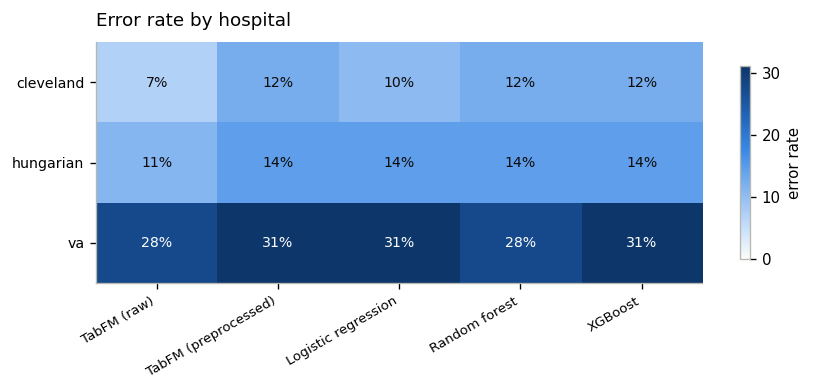

,n,TabFM (raw),TabFM (preprocessed),Logistic regression,Random forest,XGBoost
site,,,,,,
cleveland,57,0.070,0.123,0.105,0.123,0.123
hungarian,55,0.109,0.145,0.145,0.145,0.145
va,29,0.276,0.310,0.310,0.276,0.310


In [11]:
err = test[[SITE_COL, TARGET]].join(wrong)
by_site = err.groupby(SITE_COL)[list(wide.columns)].mean().round(3)
by_site.insert(0, "n", err.groupby(SITE_COL).size())

fig, ax = plt.subplots(figsize=(1.15 * len(models) + 2.4, 2.6))
grid = by_site[list(wide.columns)].to_numpy() * 100
im = ax.imshow(grid, cmap=seq_cmap(), vmin=0, vmax=max(1, grid.max()), aspect="auto")
for (r, c), v in np.ndenumerate(grid):
    ax.text(c, r, f"{v:.0f}%", ha="center", va="center", fontsize=8.5,
            color="white" if v > grid.max() * 0.55 else "#0b0b0b")
ax.set_xticks(range(len(wide.columns)), [MODEL_LABELS[m] for m in wide.columns],
              rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(by_site)), by_site.index, fontsize=8.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="error rate")
ax.set_title("Error rate by hospital", loc="left", fontsize=11, pad=10)
fig.savefig(FIGURES_DIR / "error_by_site.png")
plt.show()

by_site.rename(columns=MODEL_LABELS)

In [12]:
rows = []
for m in models:
    d = preds[preds.model == m]
    pred = (d.prob >= 0.5).astype(int)
    fn = int(((pred == 0) & (d.y_true == 1)).sum())
    fp = int(((pred == 1) & (d.y_true == 0)).sum())
    rows.append({"Model": MODEL_LABELS[m], "False negatives": fn, "False positives": fp,
                 "Missed-disease rate": round(fn / max(1, (d.y_true == 1).sum()), 3)})
errors = pd.DataFrame(rows).set_index("Model")
errors.to_csv(FIGURES_DIR / "table_7_3_error_breakdown.csv")
errors

,False negatives,False positives,Missed-disease rate
Model,,,
TabFM (raw),9,9,0.138
TabFM (preprocessed),14,10,0.215
Logistic regression,14,9,0.215
Random forest,14,9,0.215
XGBoost,15,9,0.231


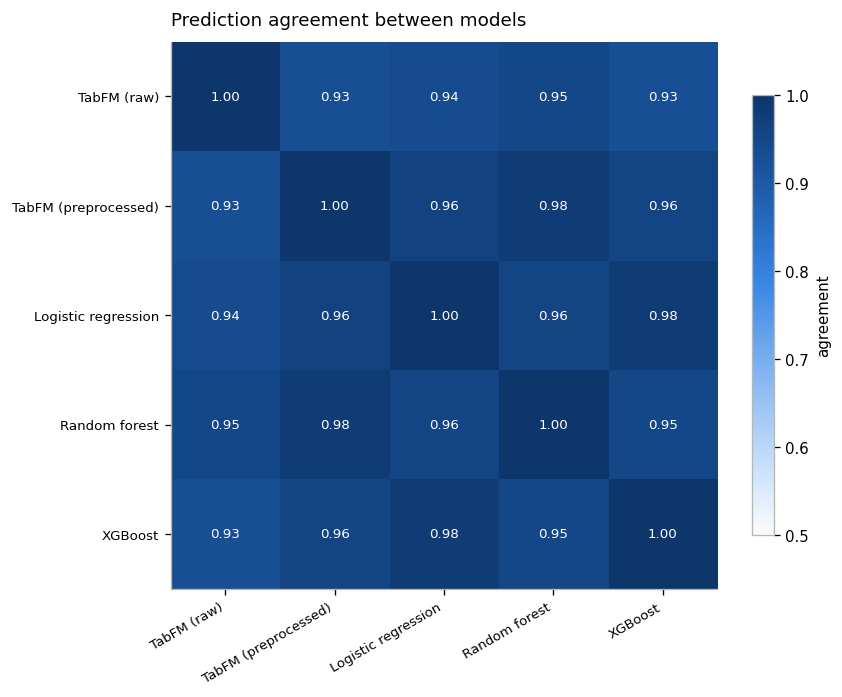

In [13]:
binary = (wide >= 0.5)
agree = pd.DataFrame(index=wide.columns, columns=wide.columns, dtype=float)
for a in wide.columns:
    for b in wide.columns:
        agree.loc[a, b] = (binary[a] == binary[b]).mean()

fig, ax = plt.subplots(figsize=(0.95 * len(models) + 2.6, 0.95 * len(models) + 1.6))
im = ax.imshow(agree.astype(float), cmap=seq_cmap(), vmin=0.5, vmax=1)
for (r, c), v in np.ndenumerate(agree.to_numpy().astype(float)):
    ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8,
            color="white" if v > 0.85 else "#0b0b0b")
labels = [MODEL_LABELS[m] for m in wide.columns]
ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="agreement")
ax.set_title("Prediction agreement between models", loc="left", fontsize=11, pad=10)
fig.savefig(FIGURES_DIR / "model_agreement.png")
plt.show()

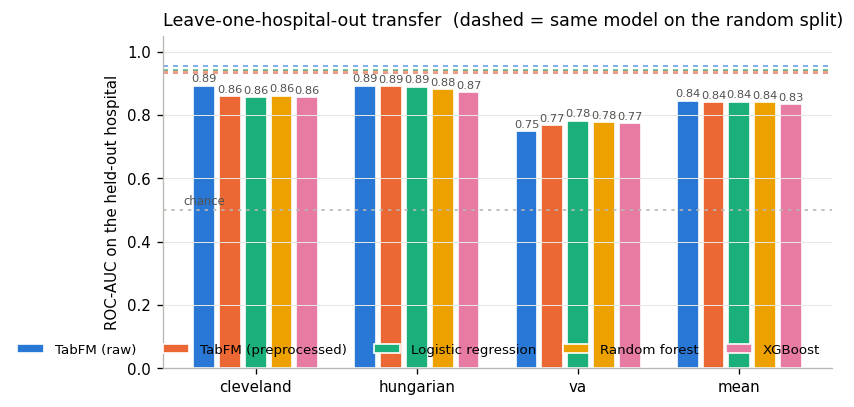

In [14]:
loho_path = FIGURES_DIR / "loho_results.csv"
if loho_path.exists():
    loho = pd.read_csv(loho_path)
    sites = sorted(loho.held_out.unique())
    lmodels = [m for m in MODEL_LABELS if m in set(loho.model)]

    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    width = 0.8 / len(lmodels)
    x = np.arange(len(sites) + 1)
    for i, m in enumerate(lmodels):
        d = loho[loho.model == m].set_index("held_out")
        vals = [d.loc[s, "roc_auc"] for s in sites] + [d["roc_auc"].mean()]
        pos = x + i * width - 0.4 + width / 2
        ax.bar(pos, vals, width * 0.85, color=MODEL_COLOURS[m],
               edgecolor="white", linewidth=1, label=MODEL_LABELS[m])
        for px, v in zip(pos, vals):
            ax.text(px, v + 0.012, f"{v:.2f}", ha="center", fontsize=6.8, color="#52514e")
        rs = results.loc[m, "roc_auc"] if m in results.index else np.nan
        if not np.isnan(rs):
            ax.axhline(rs, color=MODEL_COLOURS[m], linewidth=1,
                       linestyle=(0, (3, 3)), alpha=0.7)
    ax.axhline(0.5, color="#b8b8b3", linewidth=1, linestyle=(0, (2, 3)))
    ax.text(-0.45, 0.515, "chance", fontsize=7, color="#52514e")
    ax.set_xticks(x, [s for s in sites] + ["mean"], fontsize=9)
    ax.set_ylabel("ROC-AUC on the held-out hospital")
    ax.set_ylim(0, 1.05)
    ax.set_title("Leave-one-hospital-out transfer  (dashed = same model on the random split)",
                 loc="left", fontsize=10.5)
    ax.xaxis.grid(False)
    ax.legend(fontsize=8, loc="lower right", ncol=len(lmodels))
    fig.savefig(FIGURES_DIR / "loho_transfer.png")
    plt.show()
else:
    print("no leave-one-hospital-out results - run notebook 04 first")